# Holistic baseline comparison

Compare the returned solutions from **MORBO–RTS**, **qNParEGO–RTS**, **MORBO–STR**, **qNParEGO–STR**, and the **constant fitness-margin baseline**.

The common setting is $\gamma_{\mathrm{sync}}=\gamma_{\mathrm{grav}}=\gamma_{\mathrm{heter}}=1$, with $M=40$ octopi, four classes, simulated rewards, and $T=100$ global iterations. Each returned solution is evaluated on the same **10 fresh stochastic realizations**, separate from all training seeds.

The constant-margin baseline repeats each returned scalar threshold for the entire horizon. Its bar uses **standard hypervolume of the mean overhead–instability points**, as requested.


## Load the held-out evaluations

The simulation cache contains the measured costs for all five solution sets. Running this notebook reloads that cache and recomputes the hypervolumes; it does not rerun optimization or simulation.


In [1]:
from pathlib import Path
import hashlib
import importlib.util
import pickle
import sys

sys.dont_write_bytecode = True
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

roots = (Path.cwd(), *Path.cwd().parents)
project_root = next(
    (root for root in roots if (root / "Baselines" / "evaluate_holistic_comparison.py").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Open this notebook from the Cosmic Octopi project.")
baselines = project_root / "Baselines"
cache_path = baselines / "holistic hypervolume comparison.pkl"
if not cache_path.is_file():
    raise FileNotFoundError(
        'Run ".venv\\Scripts\\python.exe" -B "Baselines\\evaluate_holistic_comparison.py" first.'
    )
with cache_path.open("rb") as file:
    evaluation = pickle.load(file)
if evaluation.get("kind") != "holistic_held_out_hypervolume_comparison" or not evaluation.get("complete"):
    raise ValueError("The held-out comparison is not complete yet.")
for filename, digest in evaluation["input_sha256"].items():
    if hashlib.sha256((baselines / filename).read_bytes()).hexdigest() != digest:
        raise ValueError(f"The evaluated Pareto set has changed: {filename}")
for relative, digest in evaluation["evaluation_source_sha256"].items():
    if hashlib.sha256((project_root / relative).read_bytes()).hexdigest() != digest:
        raise ValueError(f"The evaluation source has changed: {relative}")
sys.path.insert(0, str(baselines))
spec = importlib.util.spec_from_file_location(
    "_holistic_comparison_evaluation", baselines / "evaluate_holistic_comparison.py"
)
comparison = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = comparison
spec.loader.exec_module(comparison)
setup = evaluation["setup"]
settings = evaluation["evaluation_settings"]
costs = np.asarray(evaluation["cost_realizations"])
assert costs.shape == (
    len(evaluation["unit_sequences"]), settings["n_realizations_per_solution"], 2
)
assert np.isfinite(costs).all() and (costs >= 0).all()
assert len(set(evaluation["scenario_seeds"])) == settings["n_realizations_per_solution"]
assert settings["baseline_hypervolume_formulation"] == "standard"
display(Markdown(
    f"**Completed held-out evaluation:** {len(evaluation['unit_sequences'])} unique solutions "
    f"× {costs.shape[1]} realizations = **{costs.shape[0] * costs.shape[1]:,} simulations**. "
    f"Each simulation spans {setup['holistic']['horizon']} global iterations."
))


**Completed held-out evaluation:** 132 unique solutions × 10 realizations = **1,320 simulations**. Each simulation spans 100 global iterations.

## Hypervolume definitions

Both objectives are minimized. Divide total overhead and total instability by the common fixed reference costs, **(2,200,000 KiB, 310)**, so the reference in normalized cost space is **(1, 1)**. All five bars use this same scale.

- **RTS:** average each solution's held-out cost realizations, then compute their standard dominated hypervolume. The two-dimensional area is computed exactly.
- **STR:** average the reference-based length scalarizations across realizations, then form their upper envelope across solutions. Integrate its squared length using the existing 128-direction midpoint rule.
- **Constant margin:** compute the exact standard two-dimensional hypervolume of the held-out mean costs. The Gaussian predictions used during search are not used for this evaluation.

For $c_{ir}$, the cost vector of solution $i$ under realization $r$, $\eta$ the cost reference, and $w_j$ a positive unit direction:

$$
\ell_{ij}^{\mathrm{STR}}
=\frac{1}{R}\sum_{r=1}^{R}
\min_{d\in\{1,2\}}
\frac{\max(1-c_{ird}/\eta_d,0)}{w_{jd}},
\qquad
\widehat{\mathrm{HV}}_{\mathrm{STR}}
=\frac{\pi}{4J}\sum_{j=1}^{J}\left(\max_i\ell_{ij}^{\mathrm{STR}}\right)^2.
$$

These are results from **one optimization run per algorithm/formulation**. The ten evaluation realizations estimate stochastic costs; they are not ten independent optimization runs.


In [2]:
summary = comparison.comparison_statistics(evaluation)
np.testing.assert_allclose(
    [row["hypervolume"] for row in summary],
    [row["hypervolume"] for row in evaluation["summary"]],
    rtol=1e-12, atol=1e-14,
)
for row in summary:
    assert np.isfinite(row["hypervolume"]) and row["hypervolume"] >= 0

table = [
    "| Method | Hypervolume metric | Returned solutions | Realizations per solution | Hypervolume |",
    "|:--|:--|--:|--:|--:|",
]
for row in summary:
    metric = "Standard" if row["formulation"] == "standard" else row["formulation"]
    table.append(
        f"| {row['algorithm']} | {metric} | {row['n_solutions']} | "
        f"{row['n_realizations']} | {row['hypervolume']:.6f} |"
    )
display(Markdown("\n".join(table)))


C:\Users\Mohamed2\Documents\Journal\Cosmic Octopi\.venv\Lib\site-packages\torch\jit\_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


| Method | Hypervolume metric | Returned solutions | Realizations per solution | Hypervolume |
|:--|:--|--:|--:|--:|
| MORBO | RTS | 8 | 10 | 0.651428 |
| qNParEGO | RTS | 6 | 10 | 0.639680 |
| MORBO | STR | 8 | 10 | 0.665184 |
| qNParEGO | STR | 10 | 10 | 0.654468 |
| Constant margin | Standard | 100 | 10 | 0.786000 |

## Hypervolume comparison

The first two bars report RTS hypervolume, the next two report STR hypervolume, and the last reports standard hypervolume for the constant-margin baseline. The vertical axis starts at zero.


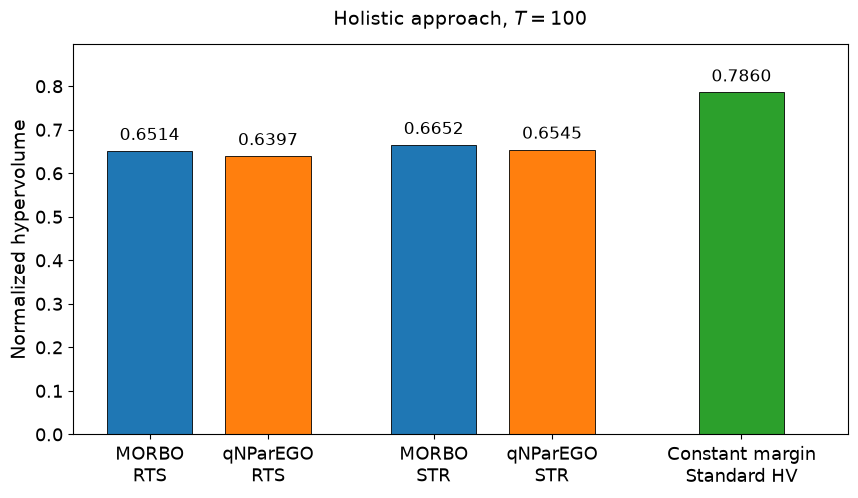

In [3]:
positions = np.array([0.0, 1.0, 2.4, 3.4, 5.0])
values = np.array([row["hypervolume"] for row in summary])
labels = ["MORBO\nRTS", "qNParEGO\nRTS", "MORBO\nSTR", "qNParEGO\nSTR",
          "Constant margin\nStandard HV"]
colors = ["#1f77b4", "#ff7f0e", "#1f77b4", "#ff7f0e", "#2ca02c"]

with plt.rc_context({"font.size": 14, "svg.fonttype": "none"}):
    fig, ax = plt.subplots(figsize=(8.8, 5.2))
    bars = ax.bar(positions, values, width=0.72, color=colors,
                  edgecolor="black", linewidth=0.6)
    ax.bar_label(bars, labels=[f"{value:.4f}" for value in values], padding=5, fontsize=12)
    ax.set_xticks(positions, labels)
    ax.set_ylabel("Normalized hypervolume", fontsize=14)
    ax.set_title(r"Holistic approach, $T=100$", fontsize=14, pad=14)
    ax.tick_params(axis="both", labelsize=13)
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.set_ylim(0, max(0.05, float(values.max()) * 1.14))
    ax.set_xlim(-0.65, 5.9)
    ax.grid(False)
    fig.tight_layout()
    figure_base = project_root / "Paper plots" / "Holistic baseline comparison"
    fig.savefig(figure_base.with_suffix(".png"), dpi=300, bbox_inches="tight")
    fig.savefig(figure_base.with_suffix(".svg"), bbox_inches="tight")
    plt.show()


## Reproducibility

The evaluation cache records the original Pareto-set hashes, the simulation settings, shared seeds, every measured cost, and the evaluation code hashes. The original search outputs are preserved.

The following check reports the numerical difference between exact RTS hypervolume and the 128-direction approximation used in the earlier optimization plots.


In [4]:
rts_rows = [row for row in summary if row["formulation"] == "RTS"]
maximum_difference = max(
    abs(row["standard_hypervolume_of_means"] - row["rts_quadrature_hypervolume"])
    for row in rts_rows
)
display(Markdown(
    f"Maximum exact-versus-quadrature RTS difference: **{maximum_difference:.6g}**.\n\n"
    f"Shared evaluation seeds: `{evaluation['scenario_seeds']}`."
))


Maximum exact-versus-quadrature RTS difference: **6.04443e-05**.

Shared evaluation seeds: `[2385971528, 3193148690, 3937333334, 2534194614, 797263586, 823411603, 2233374801, 2779230037, 3961860411, 1056997447]`.